In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
print(df.head())

# Check dataset information
print(df.info())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [2]:
# Check missing values
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [3]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [4]:
# Numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check again
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


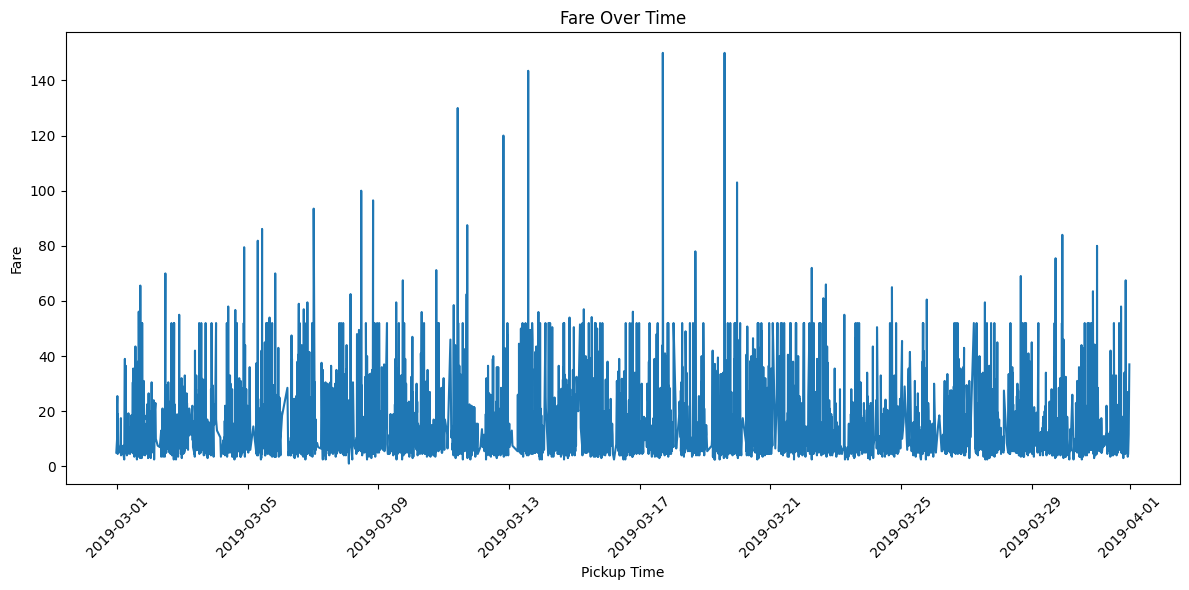

In [5]:
# Convert pickup to datetime
df["pickup"] = pd.to_datetime(df["pickup"])

# Sort by pickup time
df = df.sort_values("pickup")

# Line chart
plt.figure(figsize=(12, 6))

plt.plot(df["pickup"], df["fare"])

plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

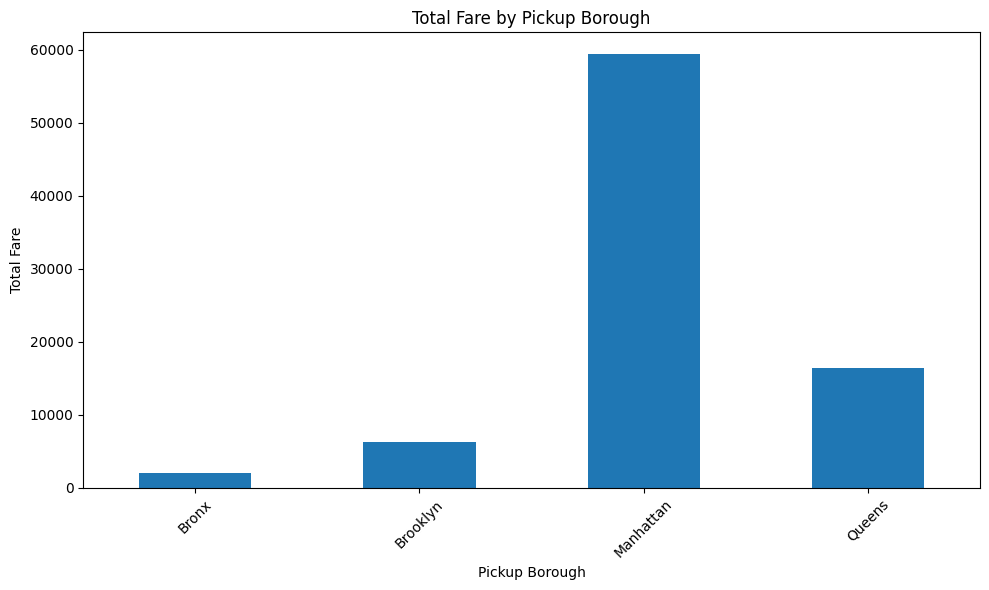

In [6]:
borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(10, 6))

borough_fare.plot(kind="bar")

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

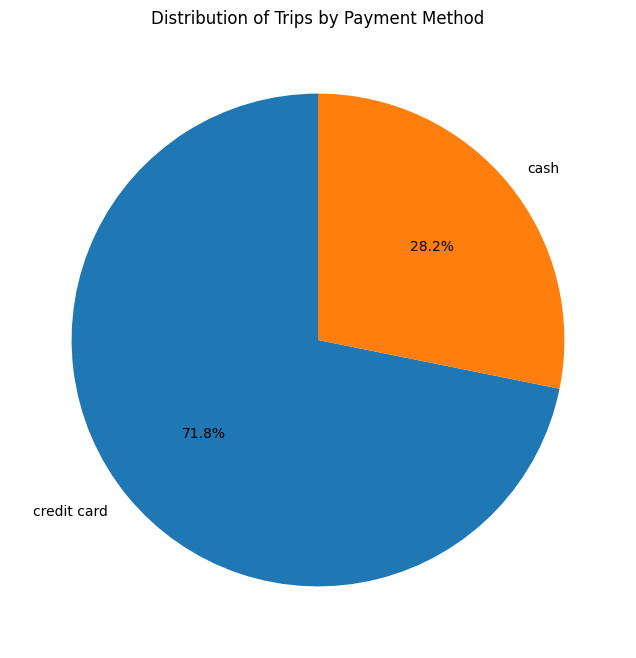

In [7]:
payment_counts = df["payment"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Trips by Payment Method")

plt.show()

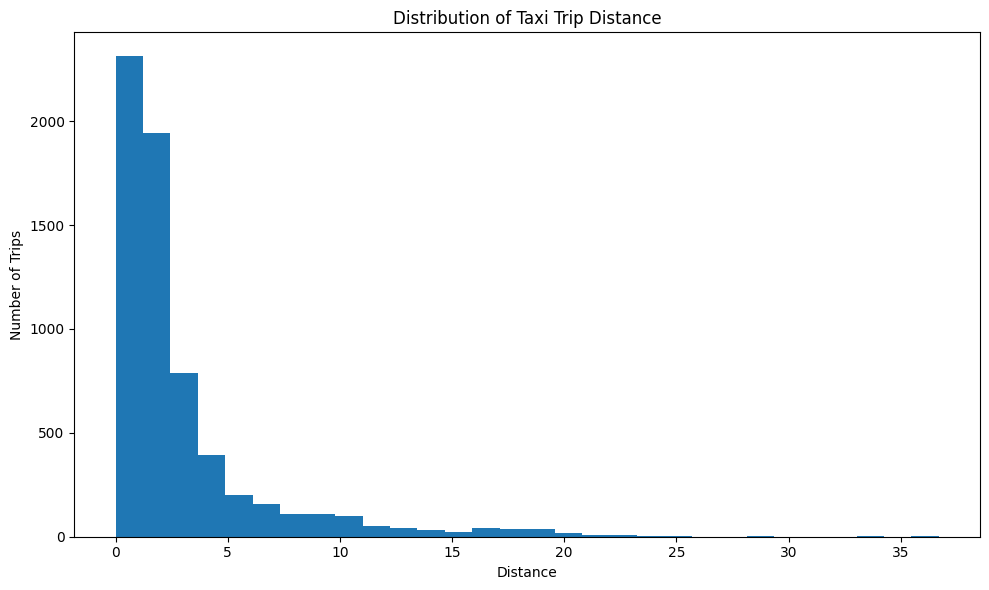

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(df["distance"], bins=30)

plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Taxi Trip Distance")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

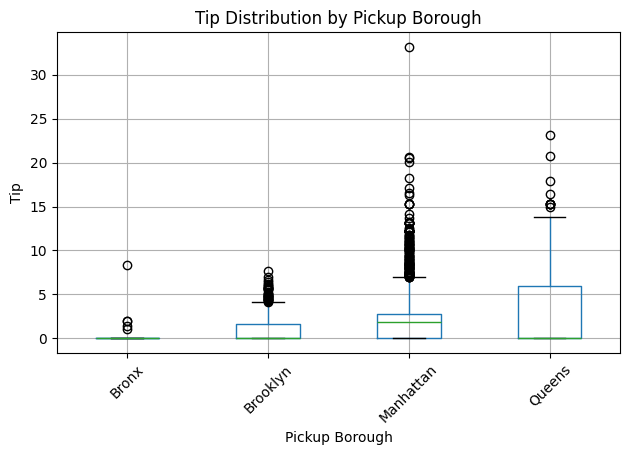

In [9]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="tip",
    by="pickup_borough"
)

plt.xlabel("Pickup Borough")
plt.ylabel("Tip")
plt.title("Tip Distribution by Pickup Borough")

plt.suptitle("")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

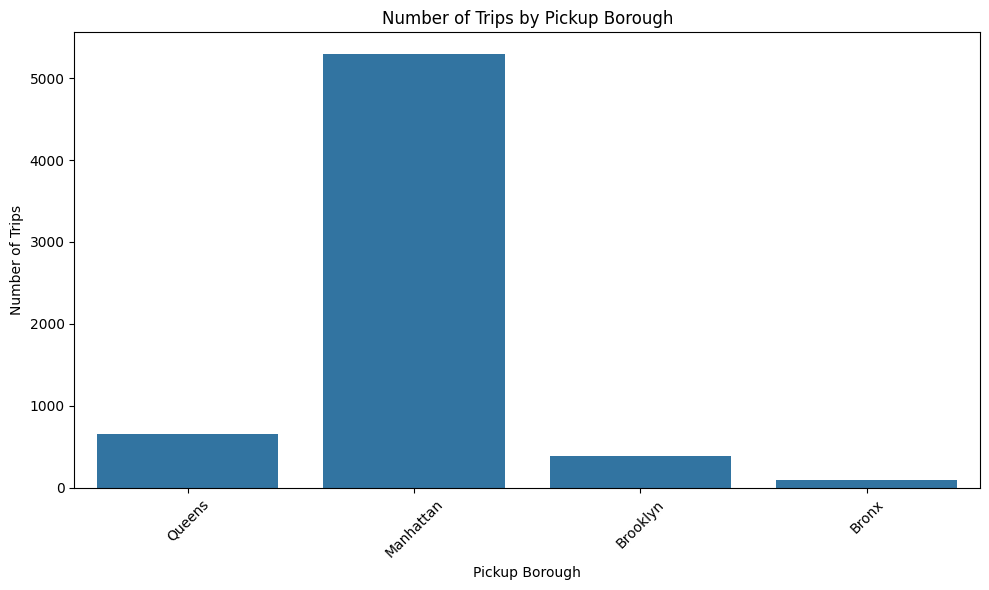

In [10]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="pickup_borough"
)

plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Pickup Borough")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

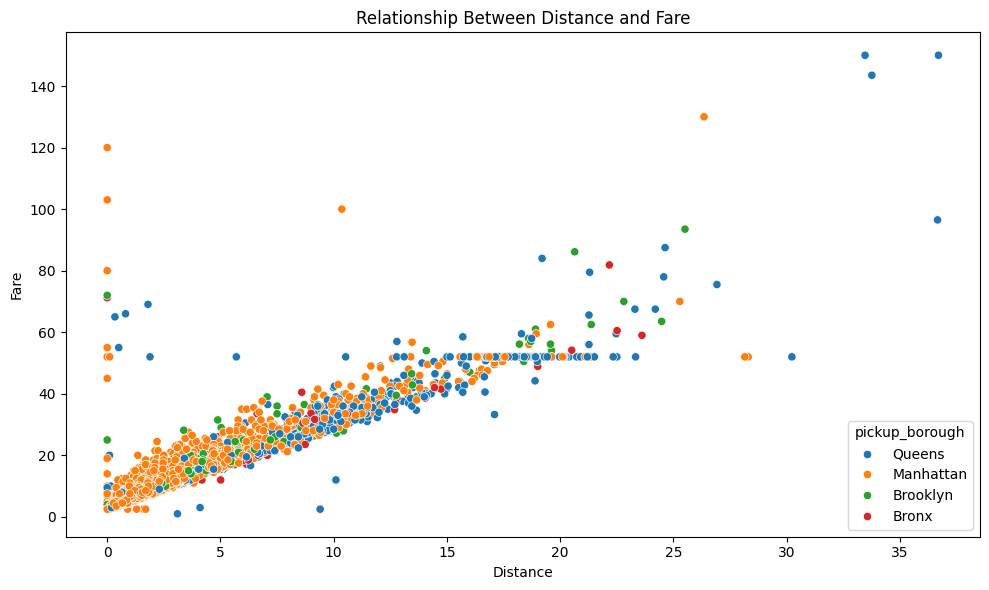

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Relationship Between Distance and Fare")

plt.tight_layout()
plt.show()

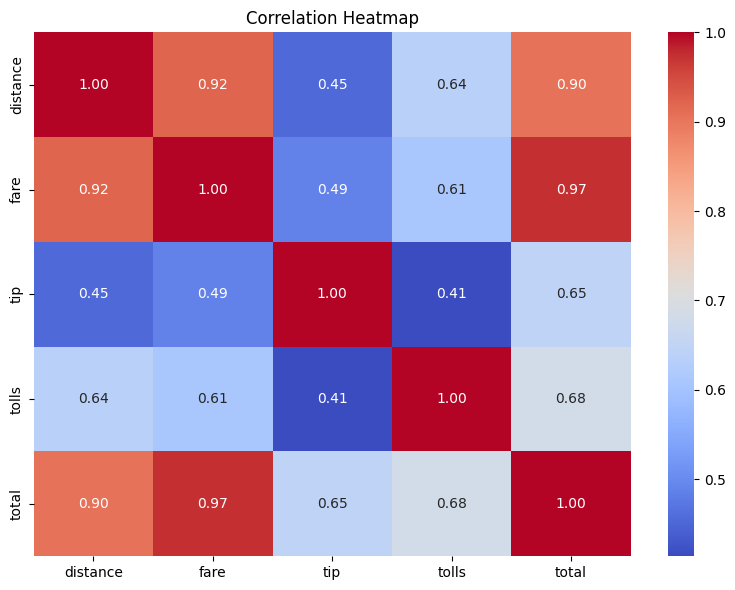

In [12]:
# Select numerical columns
numeric_data = df[
    ["distance", "fare", "tip", "tolls", "total"]
]

# Calculate correlation
correlation = numeric_data.corr()

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

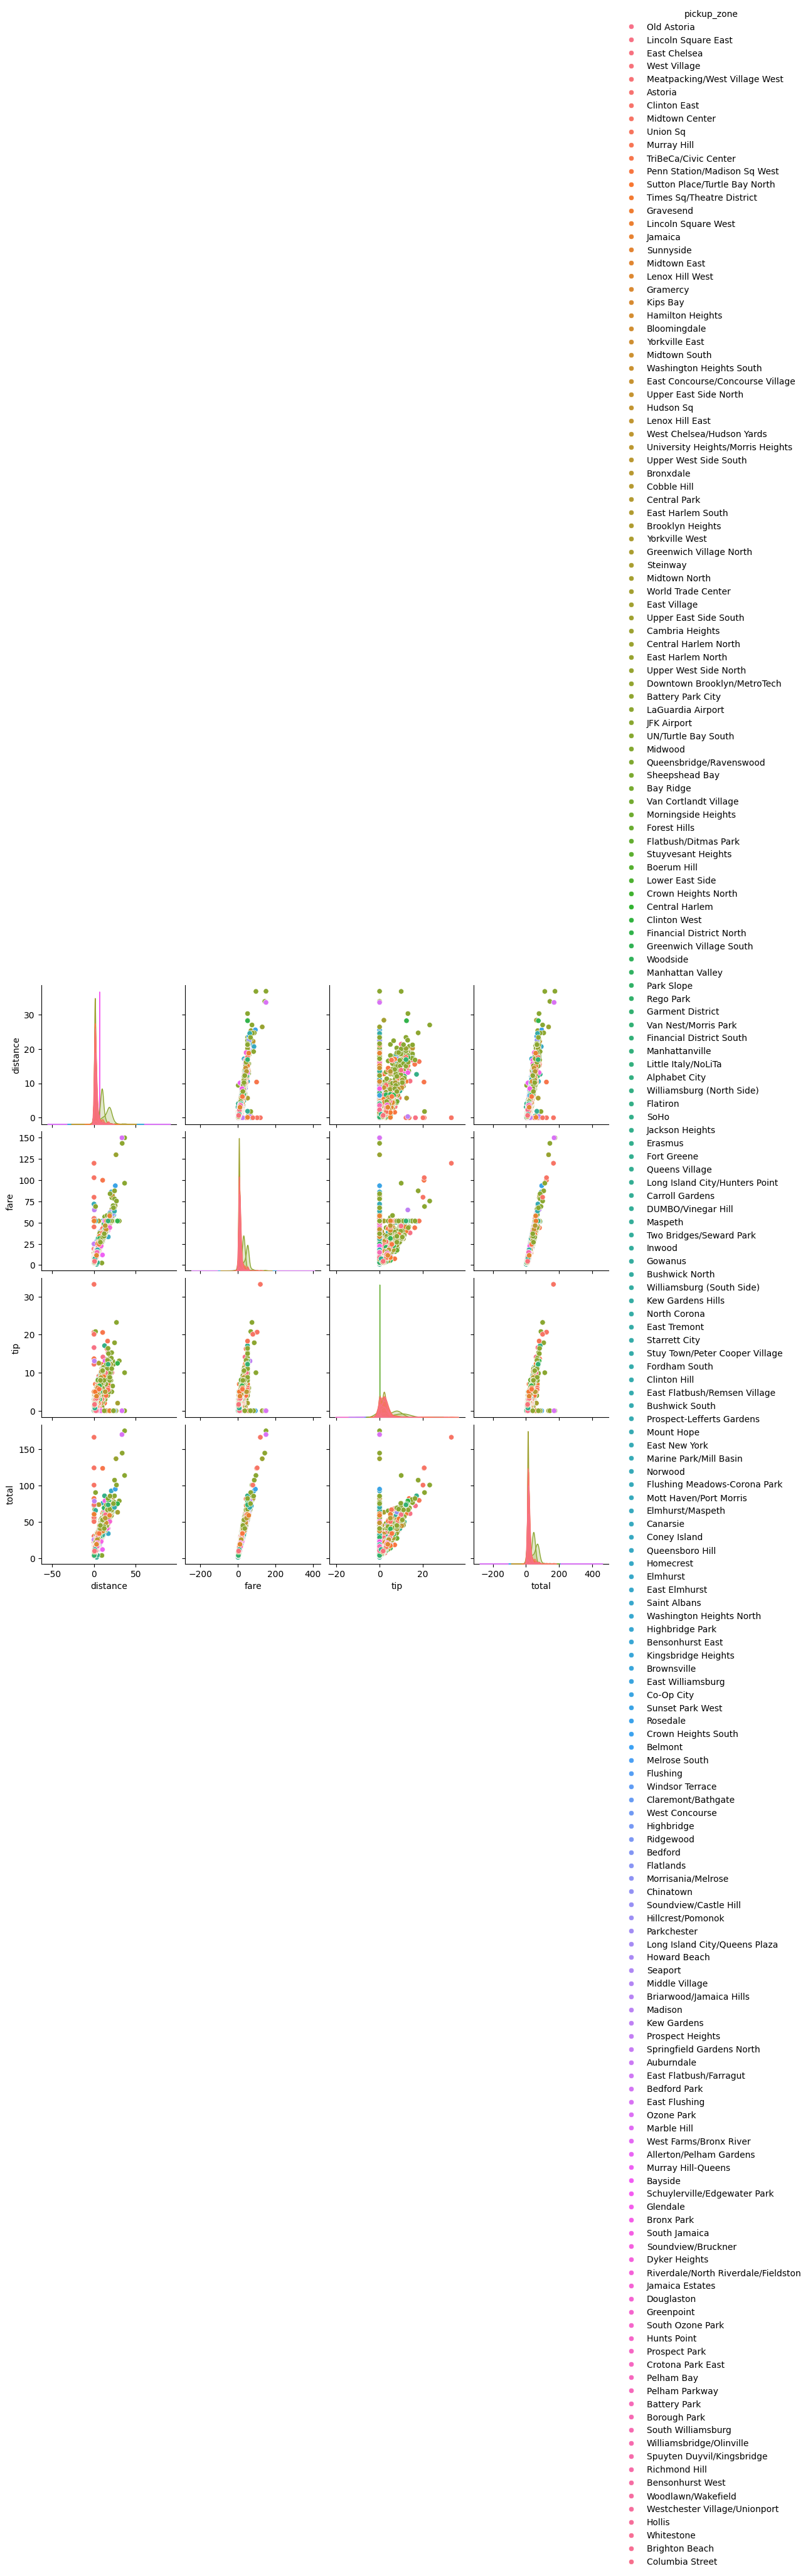

In [13]:
pair_data = df[
    ["distance", "fare", "tip", "total", "pickup_zone"]
].dropna()

sns.pairplot(
    pair_data,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()

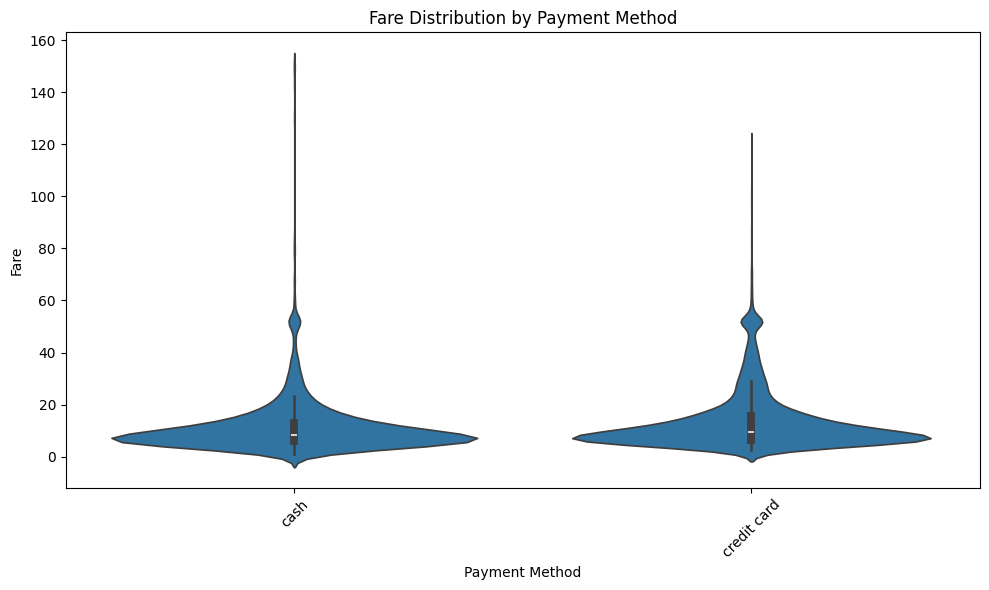

In [14]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Fare Distribution by Payment Method")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()